In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
DATASET_PATH = "/content/drive/MyDrive/Brain Tumour Classification Project/Tumour"

train_path = os.path.join(DATASET_PATH, "train")
valid_path = os.path.join(DATASET_PATH, "valid")
test_path  = os.path.join(DATASET_PATH, "test")

In [4]:
print(train_path)

/content/drive/MyDrive/Brain Tumour Classification Project/Tumour/train


# **Understand the dataset**

In [5]:
##Check Tumor Classes (Categories)

classes = [cls for cls in os.listdir(train_path)
           if os.path.isdir(os.path.join(train_path, cls))]
print("Tumor Classes: ", classes)
print("Number of classes: ", len(classes))

Tumor Classes:  ['pituitary', 'no_tumor', 'glioma', 'meningioma']
Number of classes:  4


In [6]:
##Check Class Imbalance (Count Images per Class)
from collections import Counter

def count_images(folder_path):
  class_counts = {}
  for cls in os.listdir(folder_path):
    cls_path = os.path.join(folder_path, cls)
    if os.path.isdir(cls_path):
      class_counts[cls] = len(os.listdir(cls_path))
  return class_counts

train_counts = count_images(train_path)
valid_counts = count_images(valid_path)
test_counts  = count_images(test_path)

print("Train Counts:", train_counts)
print("Validation Counts:", valid_counts)
print("Test Counts:", test_counts)

Train Counts: {'pituitary': 438, 'no_tumor': 336, 'glioma': 564, 'meningioma': 358}
Validation Counts: {'meningioma': 124, 'glioma': 161, 'pituitary': 118, 'no_tumor': 99}
Test Counts: {'meningioma': 63, 'glioma': 80, 'no_tumor': 49, 'pituitary': 54}


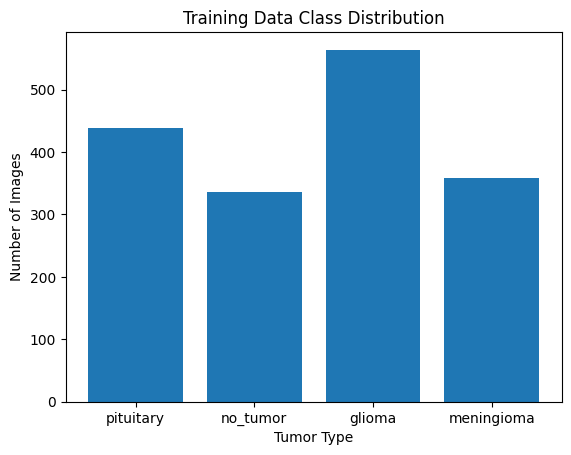

In [7]:
#Visualize Class Distribution
import matplotlib.pyplot as plt

plt.figure()
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Data Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.show()

In [8]:
##Check Image Resolution Consistency

from PIL import Image
import random

def check_image_sizes(folder_path):
    for cls in classes:
        cls_path = os.path.join(folder_path, cls)
        img_name = random.choice(os.listdir(cls_path))
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        print(f"{cls} image size:", img.size)

check_image_sizes(train_path)


pituitary image size: (640, 640)
no_tumor image size: (640, 640)
glioma image size: (640, 640)
meningioma image size: (640, 640)


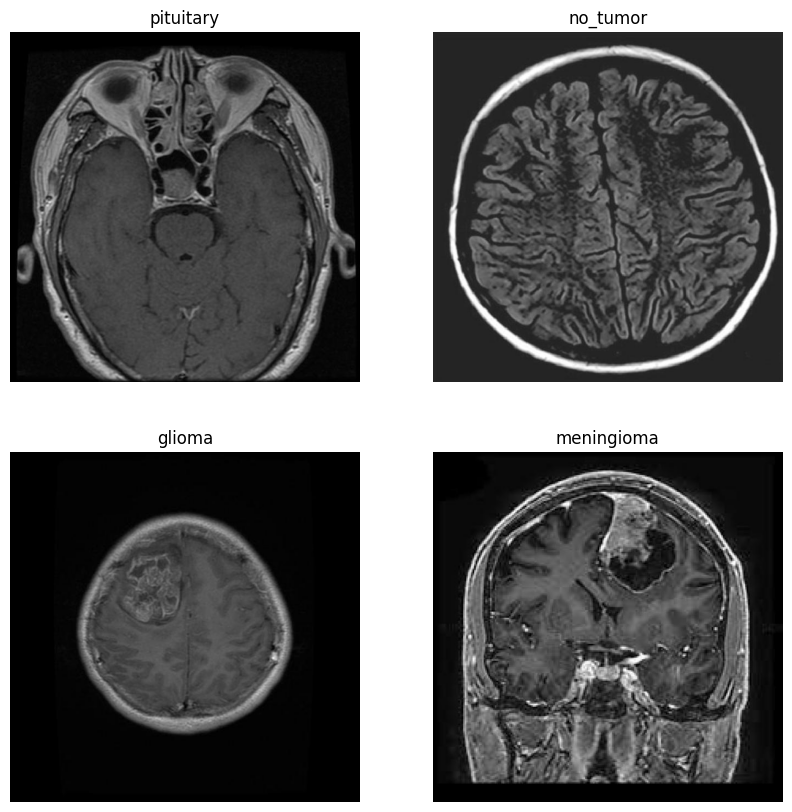

In [9]:
## Visualize Sample Images
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_sample_images(folder_path):
    plt.figure(figsize=(10,10))
    for i, cls in enumerate(classes):
        cls_path = os.path.join(folder_path, cls)
        img_name = random.choice(os.listdir(cls_path))
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)

        plt.subplot(2, 2, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(cls)
        plt.axis('off')
    plt.show()

show_sample_images(train_path)

# **2. Data Preprocessing**

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [12]:
##Create Data Generators (Resize + Normalize)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [13]:
##Load Train, Validation, Test Data

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode = 'categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1696 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


# **3. Data Augmentation**

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1696 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


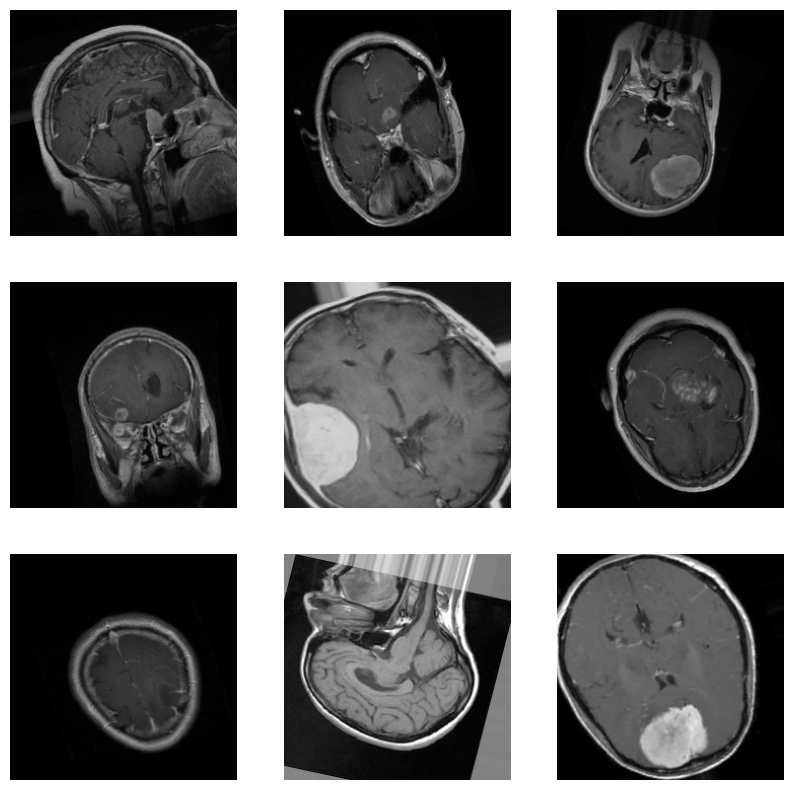

In [16]:
## Visualize Augmented Images
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

# **4. Model Building - Custom CNN**

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [18]:
model_cnn = Sequential()

#Conv2d layers
model_cnn.add(Conv2D(32, (3,3), activation = 'relu', input_shape=(224, 224, 3)))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

model_cnn.add(Conv2D(64, (3,3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

model_cnn.add(Conv2D(128, (3,3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

#Flatten
model_cnn.add(Flatten())

#Dense Layers
model_cnn.add(Dense(256, activation='relu'))
model_cnn.add(Dropout(0.5))

model_cnn.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,596 (84.86 MB)

 Trainable params: 22,246,148 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
#compile the model
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
##GPU Check

import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
##Define Callbacks

early_stop_cnn = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_cnn = ModelCheckpoint(
    "brain_tumor_cnn_model.h5",
    monitor = "val_accuracy",
    save_best_only = True
)

In [23]:
#train the model

history_cnn = model_cnn.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop_cnn, checkpoint_cnn]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4343 - loss: 20.7237

53/53 ━━━━━━━━━━━━━━━━━━━━ 686s 13s/step - accuracy: 0.4349 - loss: 20.5463 - val_accuracy: 0.2371 - val_loss: 48.1440
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 658ms/step - accuracy: 0.4807 - loss: 1.6871 - val_accuracy: 0.2351 - val_loss: 80.4688
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 643ms/step - accuracy: 0.5182 - loss: 1.1827 - val_accuracy: 0.2351 - val_loss: 59.6802
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 688ms/step - accuracy: 0.4967 - loss: 1.1777 - val_accuracy: 0.2351 - val_loss: 32.6050
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.5381 - loss: 1.1488

53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 676ms/step - accuracy: 0.5383 - loss: 1.1480 - val_accuracy: 0.2450 - val_loss: 11.7339
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.5728 - loss: 1.0870

53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 674ms/step - accuracy: 0.5725 - loss: 1.0879 - val_accuracy: 0.2649 - val_loss: 6.5882
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.5461 - loss: 1.0931

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 696ms/step - accuracy: 0.5267 - loss: 1.1230 - val_accuracy: 0.5299 - val_loss: 1.3085
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 633ms/step - accuracy: 0.5554 - loss: 0.9957 - val_accuracy: 0.4701 - val_loss: 1.4262
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.5726 - loss: 1.0357

53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 728ms/step - accuracy: 0.5726 - loss: 1.0350 - val_accuracy: 0.6275 - val_loss: 0.9530
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 649ms/step - accuracy: 0.5907 - loss: 1.0073 - val_accuracy: 0.5618 - val_loss: 1.0026
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.6046 - loss: 1.0779

53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 657ms/step - accuracy: 0.6043 - loss: 1.0772 - val_accuracy: 0.6733 - val_loss: 0.8374
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 664ms/step - accuracy: 0.5730 - loss: 1.0506 - val_accuracy: 0.6574 - val_loss: 0.8041
Epoch 14/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.5753 - loss: 1.0133

53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 673ms/step - accuracy: 0.5751 - loss: 1.0134 - val_accuracy: 0.6873 - val_loss: 0.7302
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 633ms/step - accuracy: 0.5661 - loss: 1.0111 - val_accuracy: 0.5857 - val_loss: 1.5640
Epoch 16/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.6040 - loss: 1.0334

53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 665ms/step - accuracy: 0.6042 - loss: 1.0327 - val_accuracy: 0.6912 - val_loss: 0.7048
Epoch 17/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 683ms/step - accuracy: 0.5908 - loss: 1.0271 - val_accuracy: 0.6096 - val_loss: 1.0727
Epoch 18/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 666ms/step - accuracy: 0.6144 - loss: 0.9680 - val_accuracy: 0.6773 - val_loss: 1.0788
Epoch 19/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 619ms/step - accuracy: 0.6027 - loss: 1.0193 - val_accuracy: 0.6833 - val_loss: 0.9221
Epoch 20/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 655ms/step - accuracy: 0.5855 - loss: 1.0769 - val_accuracy: 0.4343 - val_loss: 1.5554


In [24]:
def plot_history(history):
  fig = plt.figure(figsize=(10,4))

  ##Accuracy plot
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Accuracy of Model')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend(['train','test'],loc='lower right')

  ##loss plot
  plt.subplot(1,2,2)
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('loss of model')
  plt.xlabel('Epochs')
  plt.ylabel('loss')
  plt.legend(["train",'test'],loc='upper right')

  plt.tight_layout()

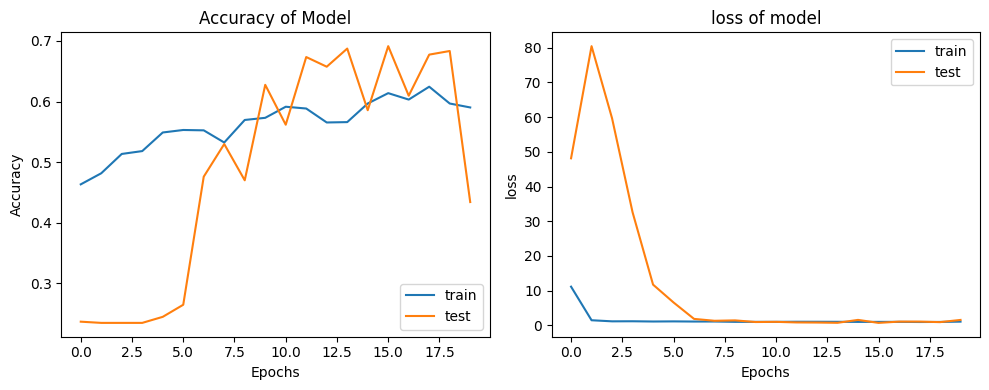

In [25]:
plot_history(history_cnn)

In [26]:
##Evaluate on Test Data
model_cnn.evaluate(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 71s 10s/step - accuracy: 0.7353 - loss: 0.7143


[0.7144685387611389, 0.707317054271698]

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = valid_generator.classes
y_pred = model_cnn.predict(valid_generator)
y_pred = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step
[[151   1   3   6]
 [ 73   2  21  28]
 [  4   4  84   7]
 [  5   0   3 110]]
              precision    recall  f1-score   support

           0       0.65      0.94      0.77       161
           1       0.29      0.02      0.03       124
           2       0.76      0.85      0.80        99
           3       0.73      0.93      0.82       118

    accuracy                           0.69       502
   macro avg       0.60      0.68      0.60       502
weighted avg       0.60      0.69      0.60       502



# **5. Transfer Learning**

EfficientNetB0

In [28]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [29]:
## load pretrained basemodel
base_model_eff = EfficientNetB0(
    weights = 'imagenet',
    include_top = False,
    input_shape= (224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
#freeze base model
base_model_eff.trainable = False

In [31]:
#add custom classification head

x = base_model_eff.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

In [32]:
#build Final model

model_eff = Model(inputs=base_model_eff.input, outputs=output)

In [33]:
model_eff.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [36]:
##Compile

model_eff.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
##Define Callbacks

early_stop_eff = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_eff = ModelCheckpoint(
    "brain_tumor_EfficientNet_model.h5",
    monitor = "val_accuracy",
    save_best_only = True
)

In [38]:
##Train Transfer Learning Model
history_eff = model_eff.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop_eff, checkpoint_eff]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.2750 - loss: 1.4343

53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 989ms/step - accuracy: 0.2753 - loss: 1.4338 - val_accuracy: 0.3207 - val_loss: 1.3727
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 621ms/step - accuracy: 0.3300 - loss: 1.3684 - val_accuracy: 0.3207 - val_loss: 1.3743
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 667ms/step - accuracy: 0.3301 - loss: 1.3636 - val_accuracy: 0.3207 - val_loss: 1.3717
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 613ms/step - accuracy: 0.3221 - loss: 1.3783 - val_accuracy: 0.3207 - val_loss: 1.3756
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 657ms/step - accuracy: 0.3013 - loss: 1.3813 - val_accuracy: 0.3207 - val_loss: 1.3762
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 617ms/step - accuracy: 0.3396 - loss: 1.3711 - val_accuracy: 0.3207 - val_loss: 1.3753
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 674ms/step - accuracy: 0.3326 - loss: 1.3658 - val_accuracy: 0.3207 - val_loss: 1.3758
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 613ms/step - accuracy: 0.3401 - loss: 1.3722 - val_accuracy: 0.320

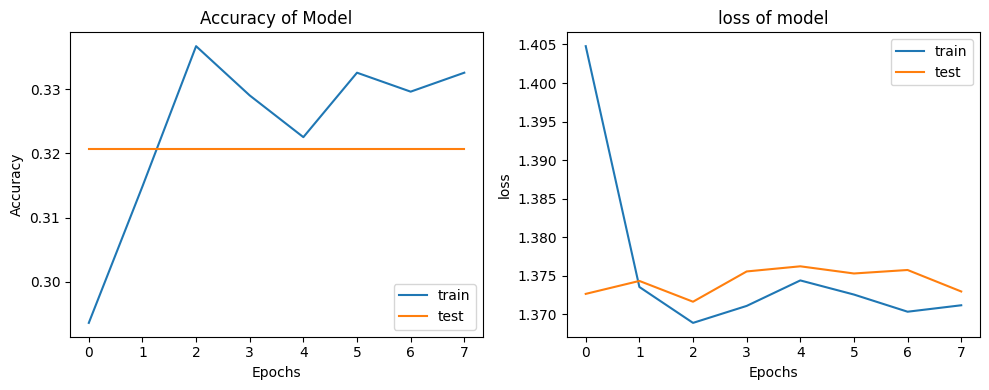

In [39]:
plot_history(history_eff)

In [40]:
##Fine-Tuning
#Unfreeze Top Layers

base_model_eff.trainable = True

for layer in base_model_eff.layers[:-20]:
    layer.trainable = False

In [41]:
#Recompile with Lower LR
model_eff.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
#Continue Training
history_eff_finetune = model_eff.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop_eff, checkpoint_eff]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 836ms/step - accuracy: 0.2922 - loss: 1.4016 - val_accuracy: 0.3207 - val_loss: 1.3717
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 633ms/step - accuracy: 0.3118 - loss: 1.3865 - val_accuracy: 0.3207 - val_loss: 1.3719
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 625ms/step - accuracy: 0.2969 - loss: 1.3708 - val_accuracy: 0.3207 - val_loss: 1.3719
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 637ms/step - accuracy: 0.2898 - loss: 1.3867 - val_accuracy: 0.3207 - val_loss: 1.3716
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 628ms/step - accuracy: 0.3097 - loss: 1.3835 - val_accuracy: 0.3207 - val_loss: 1.3711
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 628ms/step - accuracy: 0.3144 - loss: 1.3728 - val_accuracy: 0.3207 - val_loss: 1.3705
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 613ms/step - accuracy: 0.3331 - loss: 1.3668 - val_accuracy: 0.3207 - val_loss: 1.3701
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 619ms/step - accuracy: 0.3336 - loss: 1.3715 - val_accu

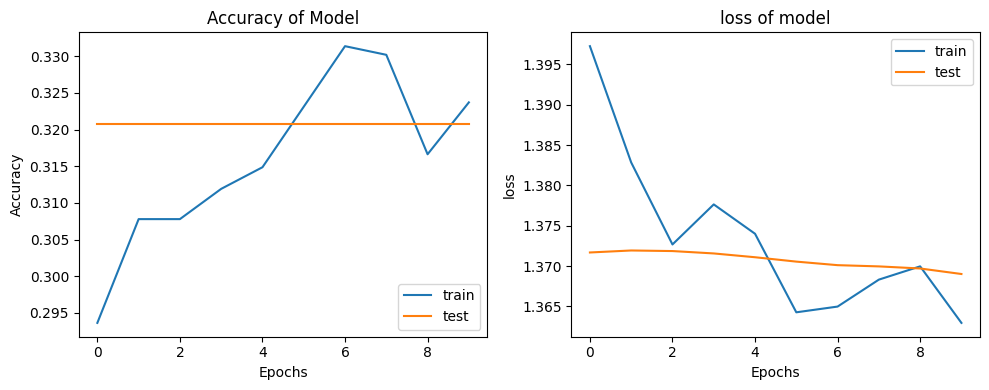

In [43]:
plot_history(history_eff_finetune)

In [44]:
model_eff.evaluate(valid_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.6381 - loss: 1.2927


[1.3690134286880493, 0.32071712613105774]

In [45]:
##Confusion matrix and classification report

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = valid_generator.classes
y_pred = model_eff.predict(valid_generator)
y_pred = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 628ms/step
[[161   0   0   0]
 [124   0   0   0]
 [ 99   0   0   0]
 [118   0   0   0]]
              precision    recall  f1-score   support

           0       0.32      1.00      0.49       161
           1       0.00      0.00      0.00       124
           2       0.00      0.00      0.00        99
           3       0.00      0.00      0.00       118

    accuracy                           0.32       502
   macro avg       0.08      0.25      0.12       502
weighted avg       0.10      0.32      0.16       502



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MibileNetV2

In [46]:
from tensorflow.keras.applications import MobileNetV2

In [47]:
base_model_mob = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model_mob.trainable = False

x = base_model_mob.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model_mob = Model(base_model_mob.input, outputs)

model_mob.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_mob = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_mob = ModelCheckpoint(
    'brain_tumor_MobileNet_model.h5',
    monitor='val_loss',
    save_best_only=True
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [48]:
history_mob = model_mob.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    callbacks=[early_stop_mob, checkpoint_mob]
)

Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.6642 - loss: 1.0241

53/53 ━━━━━━━━━━━━━━━━━━━━ 61s 886ms/step - accuracy: 0.6656 - loss: 1.0201 - val_accuracy: 0.8367 - val_loss: 0.4761
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 604ms/step - accuracy: 0.8458 - loss: 0.4585 - val_accuracy: 0.7829 - val_loss: 0.6047
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.8679 - loss: 0.4030

53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 627ms/step - accuracy: 0.8679 - loss: 0.4027 - val_accuracy: 0.8526 - val_loss: 0.4391
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 602ms/step - accuracy: 0.8827 - loss: 0.3602 - val_accuracy: 0.8108 - val_loss: 0.5025
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.8842 - loss: 0.3318

53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 607ms/step - accuracy: 0.8844 - loss: 0.3316 - val_accuracy: 0.9024 - val_loss: 0.3270
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 617ms/step - accuracy: 0.8858 - loss: 0.3507 - val_accuracy: 0.8904 - val_loss: 0.3641
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 602ms/step - accuracy: 0.9061 - loss: 0.2686 - val_accuracy: 0.8606 - val_loss: 0.4423
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 625ms/step - accuracy: 0.9112 - loss: 0.2448 - val_accuracy: 0.8725 - val_loss: 0.4157
Epoch 9/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 603ms/step - accuracy: 0.9074 - loss: 0.2306 - val_accuracy: 0.8765 - val_loss: 0.3745
Epoch 10/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 650ms/step - accuracy: 0.9060 - loss: 0.2444 - val_accuracy: 0.8944 - val_loss: 0.3672


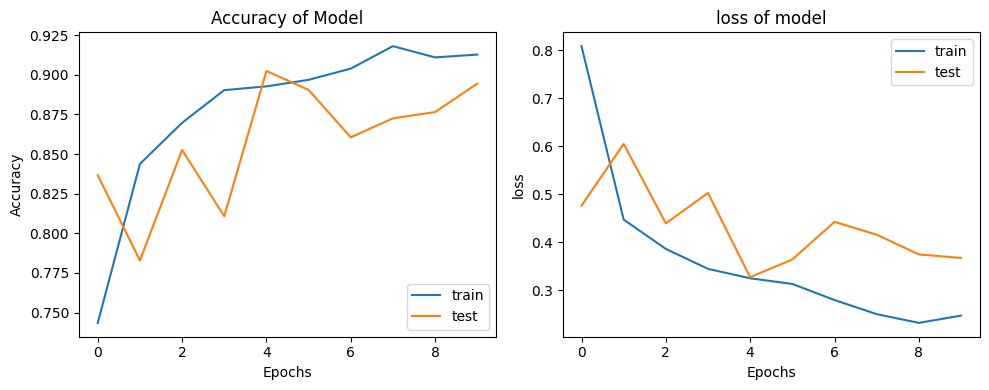

In [49]:
plot_history(history_mob)

In [50]:
model_mob.evaluate(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.8786 - loss: 0.3317


[0.36618638038635254, 0.8739837408065796]

In [51]:
#Finetuning

base_model_mob.trainable = True

for layer in base_model_mob.layers[:-30]:
    layer.trainable = False

model_mob.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # critical
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
history_mob_finetune = model_mob.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop_mob, checkpoint_mob]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 779ms/step - accuracy: 0.7575 - loss: 0.7029 - val_accuracy: 0.8247 - val_loss: 0.5016
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 636ms/step - accuracy: 0.8431 - loss: 0.4344 - val_accuracy: 0.7829 - val_loss: 0.7072
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 618ms/step - accuracy: 0.8458 - loss: 0.5010 - val_accuracy: 0.7908 - val_loss: 0.7687
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 625ms/step - accuracy: 0.8601 - loss: 0.4085 - val_accuracy: 0.7888 - val_loss: 0.8075
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 619ms/step - accuracy: 0.8524 - loss: 0.4189 - val_accuracy: 0.7948 - val_loss: 0.7975
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 662ms/step - accuracy: 0.8787 - loss: 0.3239 - val_accuracy: 0.7968 - val_loss: 0.8065


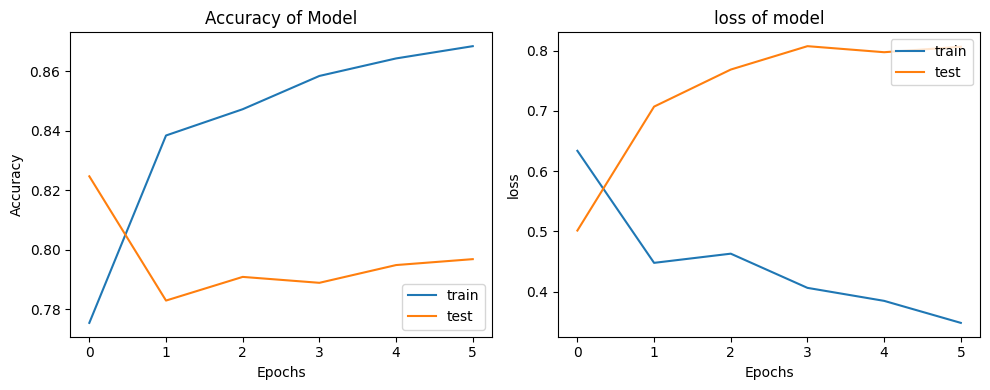

In [54]:
plot_history(history_mob_finetune)

In [55]:
model_mob.evaluate(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.8512 - loss: 0.4996


[0.668335497379303, 0.8089430928230286]

In [57]:
test_generator.reset()

y_true = test_generator.classes
y_pred = model_mob.predict(test_generator)
y_pred = np.argmax(y_pred, axis=1)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 797ms/step
[[79  1  0  0]
 [20 33  2  8]
 [ 7  5 35  2]
 [ 1  1  0 52]]
              precision    recall  f1-score   support

           0       0.74      0.99      0.84        80
           1       0.82      0.52      0.64        63
           2       0.95      0.71      0.81        49
           3       0.84      0.96      0.90        54

    accuracy                           0.81       246
   macro avg       0.84      0.80      0.80       246
weighted avg       0.82      0.81      0.80       246



ResNet50

In [58]:
from tensorflow.keras.applications import ResNet50

base_model_res = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_res.trainable = False

x = base_model_res.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(4, activation="softmax")(x)

model_res = Model(inputs=base_model_res.input, outputs=output)

model_res.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_res = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_res = ModelCheckpoint(
    'brain_tumor_ResNet_model.h5',
    monitor='val_loss',
    save_best_only=True
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [59]:
history_res = model_res.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop_res, checkpoint_res]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.3215 - loss: 1.4711

53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 801ms/step - accuracy: 0.3220 - loss: 1.4694 - val_accuracy: 0.4602 - val_loss: 1.1954
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.4266 - loss: 1.2517

53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 641ms/step - accuracy: 0.4266 - loss: 1.2519 - val_accuracy: 0.5538 - val_loss: 1.1837
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.4538 - loss: 1.2143

53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 660ms/step - accuracy: 0.4537 - loss: 1.2145 - val_accuracy: 0.6375 - val_loss: 1.1102
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 642ms/step - accuracy: 0.4710 - loss: 1.1967 - val_accuracy: 0.6195 - val_loss: 1.1126
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.4924 - loss: 1.1860

53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 646ms/step - accuracy: 0.4924 - loss: 1.1860 - val_accuracy: 0.5857 - val_loss: 1.0866
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.4795 - loss: 1.1841

53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 667ms/step - accuracy: 0.4796 - loss: 1.1839 - val_accuracy: 0.5876 - val_loss: 1.0847
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.4968 - loss: 1.1551

53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 649ms/step - accuracy: 0.4970 - loss: 1.1553 - val_accuracy: 0.5976 - val_loss: 1.0682
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.4718 - loss: 1.1928

53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 670ms/step - accuracy: 0.4721 - loss: 1.1923 - val_accuracy: 0.6175 - val_loss: 1.0594
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.5020 - loss: 1.1743

53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 693ms/step - accuracy: 0.5021 - loss: 1.1739 - val_accuracy: 0.5857 - val_loss: 1.0460
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.4876 - loss: 1.1669

53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 640ms/step - accuracy: 0.4878 - loss: 1.1666 - val_accuracy: 0.6673 - val_loss: 1.0097


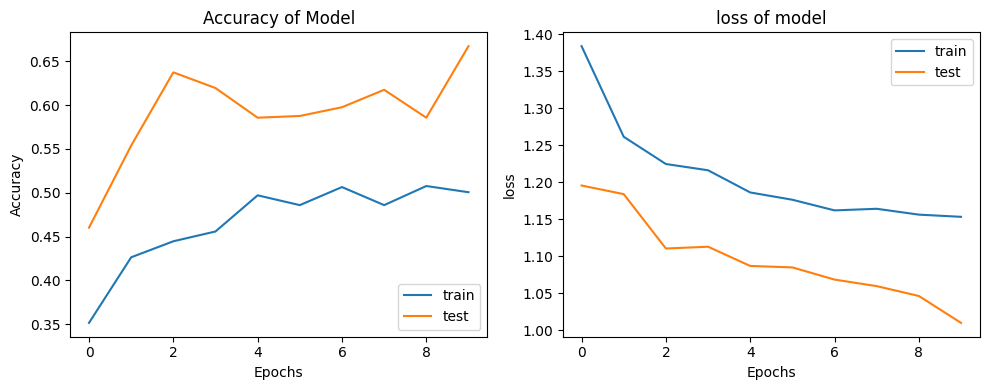

In [60]:
plot_history(history_res)

In [61]:
model_res.evaluate(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.6982 - loss: 1.0087


[1.0523961782455444, 0.6463414430618286]

In [62]:
#Finetuning

# Unfreeze last 30 layers
for layer in base_model_res.layers[-30:]:
    layer.trainable = True

model_res.compile(
    optimizer=Adam(learning_rate=1e-5),  # VERY LOW LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [63]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stop_res = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_res = ModelCheckpoint(
    'brain_tumor_ResNet_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stop_res, checkpoint_res, lr_reduce]

In [64]:
history_res_finetune = model_res.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.2169 - loss: 12.9743
Epoch 1: val_loss improved from inf to 1.44261, saving model to brain_tumor_ResNet_model.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 59s 760ms/step - accuracy: 0.2184 - loss: 12.8649 - val_accuracy: 0.2846 - val_loss: 1.4426 - learning_rate: 1.0000e-05
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.4869 - loss: 1.2298
Epoch 2: val_loss did not improve from 1.44261
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 629ms/step - accuracy: 0.4875 - loss: 1.2288 - val_accuracy: 0.1992 - val_loss: 1.8733 - learning_rate: 1.0000e-05
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.5658 - loss: 1.1578
Epoch 3: val_loss did not improve from 1.44261

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 613ms/step - accuracy: 0.5661 - loss: 1.1557 - val_accuracy: 0.2033 - val_loss: 1.8501 - learning_rate: 1.0000e-05
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.6222 - loss: 0.9674
Epoch 4: val_loss improved from 1.44261 to 1.27398, saving model to brain_tumor_ResNet_model.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 649ms/step - accuracy: 0.6223 - loss: 0.9674 - val_accuracy: 0.4431 - val_loss: 1.2740 - learning_rate: 2.0000e-06
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.6473 - loss: 0.9492
Epoch 5: val_loss improved from 1.27398 to 1.05980, saving model to brain_tumor_ResNet_model.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 629ms/step - accuracy: 0.6471 - loss: 0.9495 - val_accuracy: 0.5854 - val_loss: 1.0598 - learning_rate: 2.0000e-06
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.6212 - loss: 0.9699
Epoch 6: val_loss improved from 1.05980 to 0.93082, saving model to brain_tumor_ResNet_model.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 649ms/step - accuracy: 0.6212 - loss: 0.9696 - val_accuracy: 0.6382 - val_loss: 0.9308 - learning_rate: 2.0000e-06
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.6598 - loss: 0.9013
Epoch 7: val_loss improved from 0.93082 to 0.89716, saving model to brain_tumor_ResNet_model.h5


...

53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 641ms/step - accuracy: 0.6474 - loss: 0.8911 - val_accuracy: 0.6707 - val_loss: 0.7999 - learning_rate: 2.0000e-06
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.6847 - loss: 0.8563
Epoch 12: val_loss improved from 0.79986 to 0.76796, saving model to brain_tumor_ResNet_model.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 637ms/step - accuracy: 0.6845 - loss: 0.8564 - val_accuracy: 0.6951 - val_loss: 0.7680 - learning_rate: 2.0000e-06
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.6710 - loss: 0.8409
Epoch 13: val_loss did not improve from 0.76796
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 619ms/step - accuracy: 0.6710 - loss: 0.8410 - val_accuracy: 0.6992 - val_loss: 0.7709 - learning_rate: 2.0000e-06
Epoch 14/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.6512 - loss: 0.8611
Epoch 14: val_loss improved from 0.76796 to 0.75226, saving model to brain_tumor_ResNet_model.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 630ms/step - accuracy: 0.6515 - loss: 0.8605 - val_accuracy: 0.6829 - val_loss: 0.7523 - learning_rate: 2.0000e-06
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.6991 - loss: 0.8018
Epoch 15: val_loss improved from 0.75226 to 0.73551, saving model to brain_tumor_ResNet_model.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 660ms/step - accuracy: 0.6989 - loss: 0.8021 - val_accuracy: 0.6951 - val_loss: 0.7355 - learning_rate: 2.0000e-06
Epoch 16/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.6765 - loss: 0.8103
Epoch 16: val_loss improved from 0.73551 to 0.70263, saving model to brain_tumor_ResNet_model.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 633ms/step - accuracy: 0.6765 - loss: 0.8105 - val_accuracy: 0.7195 - val_loss: 0.7026 - learning_rate: 2.0000e-06
Epoch 17/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.7131 - loss: 0.7792
Epoch 17: val_loss did not improve from 0.70263
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 639ms/step - accuracy: 0.7130 - loss: 0.7796 - val_accuracy: 0.7114 - val_loss: 0.7059 - learning_rate: 2.0000e-06
Epoch 18/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.6895 - loss: 0.8158
Epoch 18: val_loss did not improve from 0.70263

Epoch 18: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 612ms/step - accuracy: 0.6895 - loss: 0.8158 - val_accuracy: 0.7033 - val_loss: 0.7198 - learning_rate: 2.0000e-06
Epoch 19/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.6633 - loss: 0.8188
Epoch 19: val_loss did not improve from 0.70263
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 644ms/step - accuracy: 0.6637 - loss: 0.8184 - v

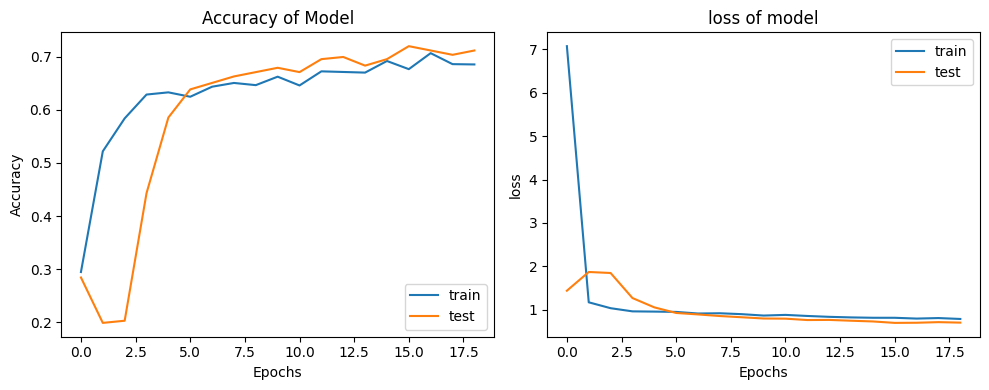

In [65]:
plot_history(history_res_finetune)

In [66]:
model_res.evaluate(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.7381 - loss: 0.6716


[0.7026308178901672, 0.7195122241973877]

In [68]:
test_generator.reset()

y_true = test_generator.classes
y_pred = model_res.predict(test_generator)
y_pred = np.argmax(y_pred, axis=1)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 714ms/step
[[71  4  2  3]
 [27 18 10  8]
 [ 3  3 38  5]
 [ 3  1  0 50]]
              precision    recall  f1-score   support

           0       0.68      0.89      0.77        80
           1       0.69      0.29      0.40        63
           2       0.76      0.78      0.77        49
           3       0.76      0.93      0.83        54

    accuracy                           0.72       246
   macro avg       0.72      0.72      0.69       246
weighted avg       0.72      0.72      0.69       246



InceptionV3

In [69]:
train_generator_incep = train_datagen.flow_from_directory(
    train_path,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical'
)

valid_generator_incep = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator_incep = test_datagen.flow_from_directory(
    test_path,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1696 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


In [70]:
from tensorflow.keras.applications import InceptionV3
base_model_incep = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)
base_model_incep.trainable = False
x = base_model_incep.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model_incep = Model(inputs=base_model_incep.input, outputs=output)
model_incep.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
callbacks_incep = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('brain_tumor_ResNet_model.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.2)
]

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [71]:
history_incep = model_incep.fit(
    train_generator_incep,
    validation_data=test_generator_incep,
    epochs=10,
    callbacks=callbacks_incep
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.5733 - loss: 1.0611

53/53 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.5753 - loss: 1.0565 - val_accuracy: 0.7886 - val_loss: 0.6083 - learning_rate: 0.0010
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.7709 - loss: 0.5939

53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 967ms/step - accuracy: 0.7713 - loss: 0.5927 - val_accuracy: 0.8008 - val_loss: 0.5574 - learning_rate: 0.0010
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.8238 - loss: 0.4623

53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 974ms/step - accuracy: 0.8238 - loss: 0.4624 - val_accuracy: 0.7967 - val_loss: 0.5376 - learning_rate: 0.0010
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.8305 - loss: 0.4449

53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 961ms/step - accuracy: 0.8305 - loss: 0.4449 - val_accuracy: 0.8130 - val_loss: 0.5315 - learning_rate: 0.0010
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.8397 - loss: 0.4310

53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 973ms/step - accuracy: 0.8395 - loss: 0.4310 - val_accuracy: 0.8293 - val_loss: 0.4229 - learning_rate: 0.0010
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.8416 - loss: 0.4058

53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 967ms/step - accuracy: 0.8417 - loss: 0.4054 - val_accuracy: 0.8455 - val_loss: 0.4162 - learning_rate: 0.0010
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8745 - loss: 0.3232 - val_accuracy: 0.8455 - val_loss: 0.4347 - learning_rate: 0.0010
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.8747 - loss: 0.3300

53/53 ━━━━━━━━━━━━━━━━━━━━ 78s 948ms/step - accuracy: 0.8747 - loss: 0.3303 - val_accuracy: 0.8496 - val_loss: 0.4028 - learning_rate: 0.0010
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 925ms/step - accuracy: 0.8710 - loss: 0.3532

53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 981ms/step - accuracy: 0.8713 - loss: 0.3530 - val_accuracy: 0.8577 - val_loss: 0.3880 - learning_rate: 0.0010
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 989ms/step - accuracy: 0.8764 - loss: 0.3519 - val_accuracy: 0.8577 - val_loss: 0.4177 - learning_rate: 0.0010


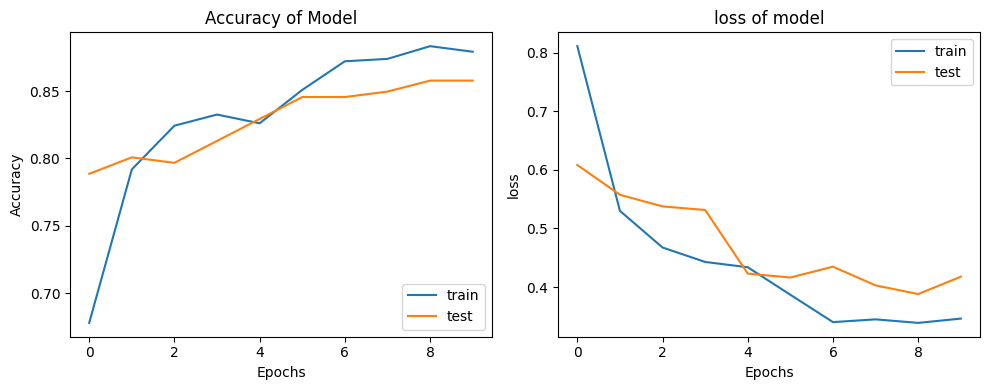

In [72]:
plot_history(history_incep)

In [73]:
model_incep.evaluate(test_generator_incep)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.8506 - loss: 0.4237


[0.38800302147865295, 0.857723593711853]

In [74]:
#Finetuning

for layer in base_model_incep.layers[-40:]:
    layer.trainable = True

model_incep.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_incep_finetune = model_incep.fit(
    train_generator_incep,
    validation_data=test_generator_incep,
    epochs=10,
    callbacks=callbacks_incep
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.4817 - loss: 1.7469 - val_accuracy: 0.8415 - val_loss: 0.4634 - learning_rate: 1.0000e-05
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 994ms/step - accuracy: 0.7540 - loss: 0.7948 - val_accuracy: 0.8252 - val_loss: 0.4811 - learning_rate: 1.0000e-05
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 993ms/step - accuracy: 0.8383 - loss: 0.4554 - val_accuracy: 0.8171 - val_loss: 0.4744 - learning_rate: 1.0000e-05
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.8639 - loss: 0.3831 - val_accuracy: 0.8496 - val_loss: 0.4204 - learning_rate: 2.0000e-06
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.8593 - loss: 0.3955 - val_accuracy: 0.8618 - val_loss: 0.3983 - learning_rate: 2.0000e-06
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 989ms/step - accuracy: 0.8635 - loss: 0.3779 - val_accuracy: 0.8618 - val_loss: 0.3882 - learning_rate: 2.0000e-06
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 968ms/step - accuracy: 0.8

53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8805 - loss: 0.3798 - val_accuracy: 0.8618 - val_loss: 0.3827 - learning_rate: 2.0000e-06
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.8873 - loss: 0.3401

53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8874 - loss: 0.3398 - val_accuracy: 0.8618 - val_loss: 0.3791 - learning_rate: 2.0000e-06
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.8827 - loss: 0.3586

53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8825 - loss: 0.3589 - val_accuracy: 0.8740 - val_loss: 0.3694 - learning_rate: 2.0000e-06
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.8927 - loss: 0.3273

53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 981ms/step - accuracy: 0.8927 - loss: 0.3274 - val_accuracy: 0.8740 - val_loss: 0.3647 - learning_rate: 2.0000e-06


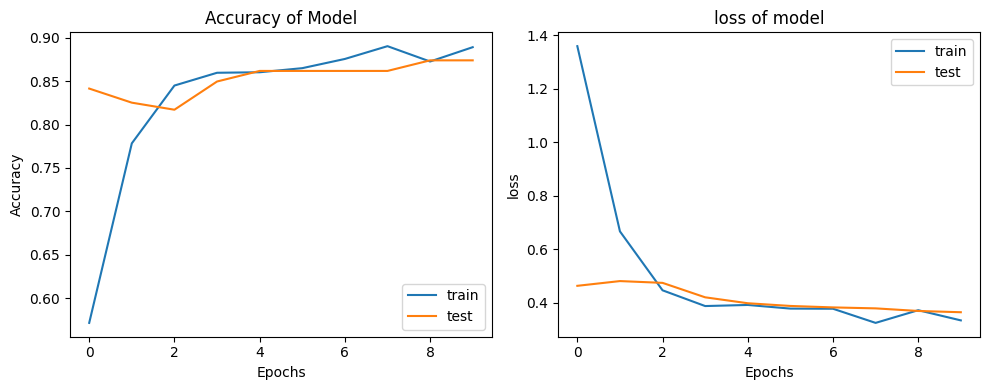

In [75]:
plot_history(history_incep_finetune)

In [76]:
model_incep.evaluate(test_generator_incep)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.8612 - loss: 0.4138


[0.3647051155567169, 0.8739837408065796]

In [77]:
cnn_loss, cnn_acc = model_cnn.evaluate(test_generator)

eff_loss, eff_acc = model_eff.evaluate(test_generator)

mob_loss, mob_acc = model_mob.evaluate(test_generator)

res_loss, res_acc = model_res.evaluate(test_generator)

incep_loss, incep_acc = model_incep.evaluate(test_generator_incep)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.7353 - loss: 0.7143
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.5981 - loss: 1.3033
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.8512 - loss: 0.4996
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.7381 - loss: 0.6716
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step - accuracy: 0.8612 - loss: 0.4138


In [78]:
import pandas as pd

results = {
    "Model": [
        "Custom CNN (Baseline)",
        "EfficientNetB0",
        "MobileNet",
        "ResNet50",
        "InceptionV3"
    ],
    "Test Accuracy (%)": [
        cnn_acc * 100,
        eff_acc * 100,
        mob_acc * 100,
        res_acc * 100,
        incep_acc * 100
    ],
    "Test Loss": [
        cnn_loss,
        eff_loss,
        mob_loss,
        res_loss,
        incep_loss
    ]
}

df_results = pd.DataFrame(results)
df_results.sort_values(by="Test Accuracy (%)", ascending=False)

,Model,Test Accuracy (%),Test Loss
4,InceptionV3,87.398374,0.364705
2,MobileNet,80.894309,0.668335
3,ResNet50,71.951222,0.702631
0,Custom CNN (Baseline),70.731705,0.714469
1,EfficientNetB0,32.520324,1.369466


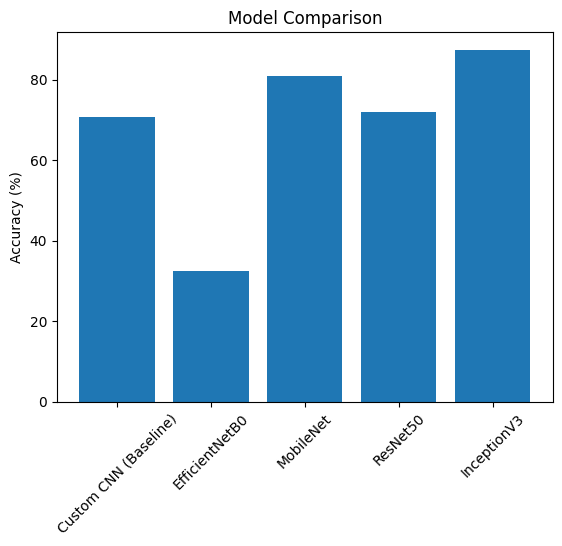

In [79]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_results["Model"], df_results["Test Accuracy (%)"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.show()

**InceptionV3 is the BEST choice**

1️⃣ Highest Test Accuracy

87.39% is the highest among all models

Indicates best generalization on unseen MRI images

2️⃣ Lowest Test Loss

Test loss 0.36 (much lower than others)

Means predictions are:

more confident

less error-prone

👉 High accuracy + low loss = strong, reliable model

3️⃣ Consistent Performance

InceptionV3:

Learns multi-scale features (important in MRI images)

Handles variations in tumor size and shape better

This is especially suitable for medical image classification.

4️⃣ Other Models – Why NOT them?

❌ EfficientNetB0

Very poor accuracy (32%)

Indicates:

underfitting

or incorrect fine-tuning / preprocessing

❌ Not safe to use

⚠️ Custom CNN

Acceptable for baseline

But significantly worse than pretrained models

⚠️ ResNet50

Lower accuracy than expected

Possibly:

needs more fine-tuning

or learning rate issues

⚠️ MobileNet

Good accuracy (80.9%)

BUT:

Lower than InceptionV3

Chosen mainly when deployment on low-end devices is required

In [80]:
import pickle

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

with open("class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

In [81]:
import pickle

model_incep.save("/content/drive/MyDrive/brain_tumor_models/best_model_inceptionv3.h5")

with open("/content/drive/MyDrive/brain_tumor_models/class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)